In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path
from sklearn.linear_model import LinearRegression, Ridge
from sklearn.metrics import mean_squared_error, mean_absolute_error
from sklearn.model_selection import train_test_split

In [2]:
df = pd.read_csv(Path("household_power_consumption.txt"), sep=";", na_values="?")

df['datetime'] = pd.to_datetime(df['Date'] + ' ' + df['Time'], dayfirst=True)
df = df.dropna(subset=['Global_active_power'])

# Convert to hourly data
df = df.set_index('datetime')
df_hourly = df['Global_active_power'].resample('h').mean().dropna()
df_hourly = df_hourly.reset_index()
df_hourly.columns = ['datetime', 'power']

df_hourly['hour']      = df_hourly['datetime'].dt.hour
df_hourly['day_of_week'] = df_hourly['datetime'].dt.dayofweek
df_hourly['day_of_year'] = df_hourly['datetime'].dt.dayofyear

In [3]:
print(df.shape)
df.head()

(2049280, 9)


,Date,Time,Global_active_power,Global_reactive_power,Voltage,Global_intensity,Sub_metering_1,Sub_metering_2,Sub_metering_3
datetime,,,,,,,,,
2006-12-16 17:24:00,16/12/2006,17:24:00,4.216,0.418,234.84,18.4,0.0,1.0,17.0
2006-12-16 17:25:00,16/12/2006,17:25:00,5.360,0.436,233.63,23.0,0.0,1.0,16.0
2006-12-16 17:26:00,16/12/2006,17:26:00,5.374,0.498,233.29,23.0,0.0,2.0,17.0
2006-12-16 17:27:00,16/12/2006,17:27:00,5.388,0.502,233.74,23.0,0.0,1.0,17.0
2006-12-16 17:28:00,16/12/2006,17:28:00,3.666,0.528,235.68,15.8,0.0,1.0,17.0


In [4]:
print(df_hourly.shape)
df_hourly.head()

(34168, 5)


,datetime,power,hour,day_of_week,day_of_year
0,2006-12-16 17:00:00,4.222889,17,5,350
1,2006-12-16 18:00:00,3.632200,18,5,350
2,2006-12-16 19:00:00,3.400233,19,5,350
3,2006-12-16 20:00:00,3.268567,20,5,350
4,2006-12-16 21:00:00,3.056467,21,5,350


In [5]:
def fourier_features(df, K_hour=5, K_week=3, K_year=3):
    features = {}
    
    # Hour of day (period = 24)
    for k in range(1, K_hour + 1):
        features[f'sin_hour_{k}'] = np.sin(2 * np.pi * k * df['hour'] / 24)
        features[f'cos_hour_{k}'] = np.cos(2 * np.pi * k * df['hour'] / 24)
    
    # Day of week (period = 7)
    for k in range(1, K_week + 1):
        features[f'sin_week_{k}'] = np.sin(2 * np.pi * k * df['day_of_week'] / 7)
        features[f'cos_week_{k}'] = np.cos(2 * np.pi * k * df['day_of_week'] / 7)
    
    # Day of year (period = 365)
    for k in range(1, K_year + 1):
        features[f'sin_year_{k}'] = np.sin(2 * np.pi * k * df['day_of_year'] / 365)
        features[f'cos_year_{k}'] = np.cos(2 * np.pi * k * df['day_of_year'] / 365)
    
    return pd.DataFrame(features, index=df.index)

In [6]:
X = fourier_features(df_hourly)
y = df_hourly['power'].values
print("Feature matrix shape:", X.shape)

Feature matrix shape: (34168, 22)


In [7]:
# Splitting by time
split = int(len(X) * 0.8)
X_train, X_test = X.iloc[:split], X.iloc[split:]
y_train, y_test = y[:split], y[split:]

print(f"Train: {len(X_train)} | Test: {len(X_test)}")

Train: 27334 | Test: 6834


In [8]:
# Training the OLS and Ridge Models

ols = LinearRegression()
ols.fit(X_train, y_train)
y_pred_ols = ols.predict(X_test)

ridge = Ridge(alpha=1.0)
ridge.fit(X_train, y_train)
y_pred_ridge = ridge.predict(X_test)

def evaluate(name, y_true, y_pred):
    rmse = np.sqrt(mean_squared_error(y_true, y_pred))
    mae  = mean_absolute_error(y_true, y_pred)
    print(f"{name:10s} | RMSE: {rmse:.4f} | MAE: {mae:.4f}")

evaluate("OLS",   y_test, y_pred_ols)
evaluate("Ridge", y_test, y_pred_ridge)

OLS        | RMSE: 0.6396 | MAE: 0.4902
Ridge      | RMSE: 0.6396 | MAE: 0.4902


In [9]:
# Resultsb of training with different K values for Fourier features

results = []

for K in [1, 3, 5, 10]:
    X_k = fourier_features(df_hourly, K_hour=K, K_week=0, K_year=0)
    X_tr, X_te = X_k.iloc[:split], X_k.iloc[split:]
    
    for name, model in [("OLS", LinearRegression()), ("Ridge", Ridge(alpha=1.0))]:
        model.fit(X_tr, y_train)
        pred = model.predict(X_te)
        rmse = np.sqrt(mean_squared_error(y_test, pred))
        results.append({'K': K, 'model': name, 'RMSE': rmse})

results_df = pd.DataFrame(results)
print(results_df)

    K  model      RMSE
0   1    OLS  0.726939
1   1  Ridge  0.726938
2   3    OLS  0.680856
3   3  Ridge  0.680851
4   5    OLS  0.672198
5   5  Ridge  0.672193
6  10    OLS  0.669986
7  10  Ridge  0.669981


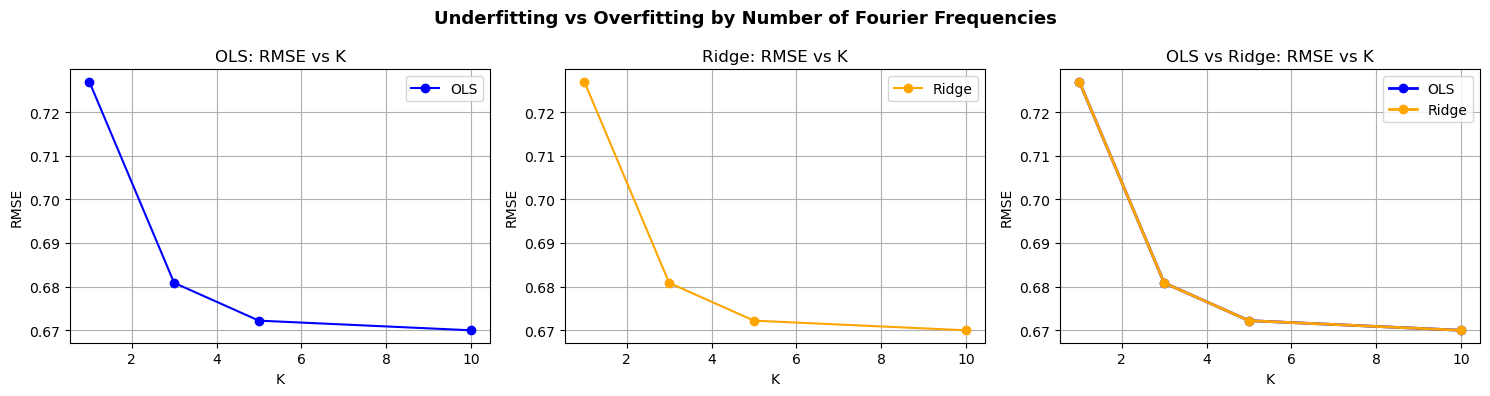

In [15]:
# Plotting experiment with K values

fig, axes = plt.subplots(1, 3, figsize=(15, 4))

# Plot 1: OLS only
axes[0].plot(results_df[results_df['model']=='OLS']['K'],
             results_df[results_df['model']=='OLS']['RMSE'],
             marker='o', color='blue', label='OLS')
axes[0].set_title('OLS: RMSE vs K')
axes[0].set_xlabel('K')
axes[0].set_ylabel('RMSE')
axes[0].grid(True)
axes[0].legend()

# Plot 2: Ridge only
axes[1].plot(results_df[results_df['model']=='Ridge']['K'],
             results_df[results_df['model']=='Ridge']['RMSE'],
             marker='o', color='orange', label='Ridge')
axes[1].set_title('Ridge: RMSE vs K')
axes[1].set_xlabel('K')
axes[1].set_ylabel('RMSE')
axes[1].grid(True)
axes[1].legend()

# Plot 3: together
for name, color in [('OLS', 'blue'), ('Ridge', 'orange')]:
    subset = results_df[results_df['model'] == name]
    axes[2].plot(subset['K'], subset['RMSE'],
                 marker='o', label=name, color=color,
                 linewidth=2)
axes[2].set_title('OLS vs Ridge: RMSE vs K')
axes[2].set_xlabel('K')
axes[2].set_ylabel('RMSE')
axes[2].grid(True)
axes[2].legend()

plt.suptitle('Underfitting vs Overfitting by Number of Fourier Frequencies', 
             fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig('../figures/rmse_vs_K.png', dpi=150)
plt.show()

In [11]:
# Trying to force overfitting by using very high K values

for K in [1, 5, 10, 20, 50]:
    X_k = fourier_features(df_hourly, K_hour=K, K_week=0, K_year=0)

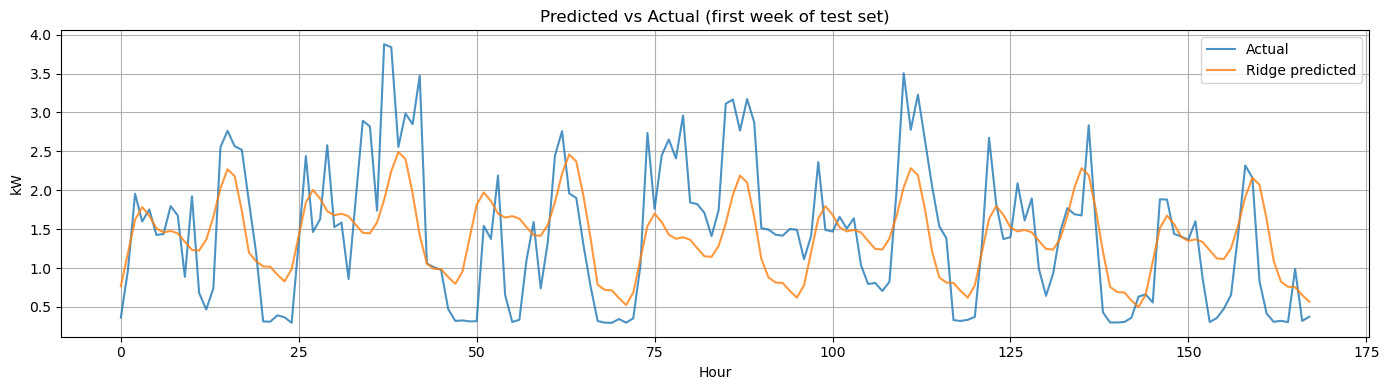

In [12]:
# Plotting the predictions vs actual for the first week of the test set

n_plot = 24 * 7  # one week
plt.figure(figsize=(14, 4))


plt.plot(y_test[:n_plot], label='Actual', alpha=0.8)
plt.plot(y_pred_ridge[:n_plot], label='Ridge predicted', alpha=0.8)
plt.title('Predicted vs Actual (first week of test set)')
plt.xlabel('Hour')
plt.ylabel('kW')
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.savefig('../figures/predictions_vs_actual.png')
plt.show()

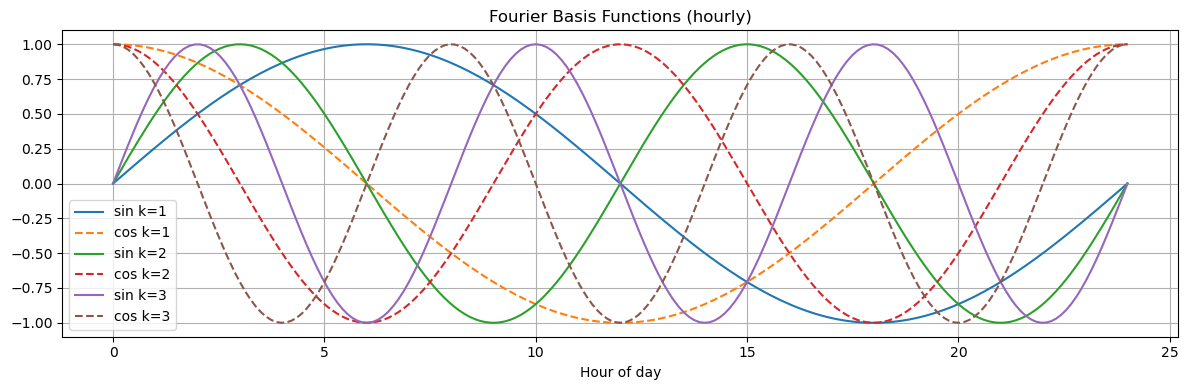

In [13]:
# Plotting Fourier Basis Functions

hours = np.linspace(0, 24, 200)
plt.figure(figsize=(12, 4))
for k in [1, 2, 3]:
    plt.plot(hours, np.sin(2 * np.pi * k * hours / 24), label=f'sin k={k}')
    plt.plot(hours, np.cos(2 * np.pi * k * hours / 24), '--', label=f'cos k={k}')
plt.title('Fourier Basis Functions (hourly)')
plt.xlabel('Hour of day')
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.savefig('../figures/fourier_basis.png')
plt.show()

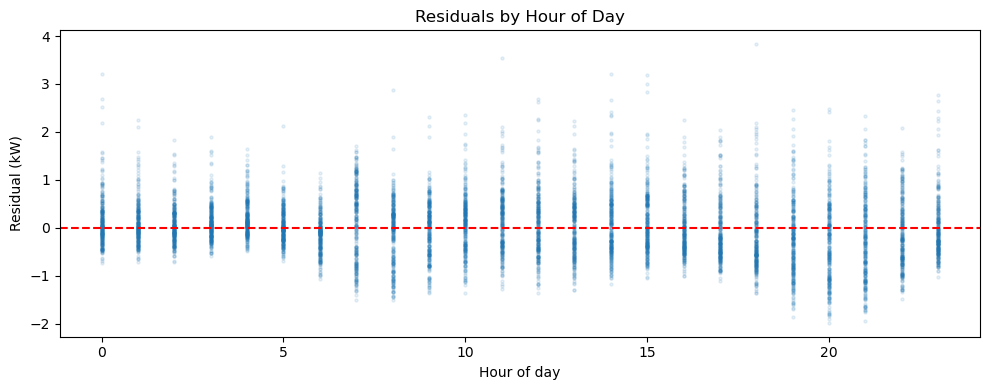

In [14]:
# Plotting residuals by hour of day

residuals = y_test - y_pred_ridge
test_hours = df_hourly['hour'].values[split:]

plt.figure(figsize=(10, 4))
plt.scatter(test_hours, residuals, alpha=0.1, s=5)
plt.axhline(0, color='red', linestyle='--')
plt.xlabel('Hour of day')
plt.ylabel('Residual (kW)')
plt.title('Residuals by Hour of Day')
plt.tight_layout()
plt.savefig('../figures/residuals_by_hour.png')
plt.show()